### Import Packages

In [56]:
# Importing some useful packages
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
import numpy as np
import cv2

# This sets up matplotlib's interactive mode
%matplotlib inline

### Reading in an Image

This image is :  <class 'numpy.ndarray'> with dimensions:  (540, 960, 3)


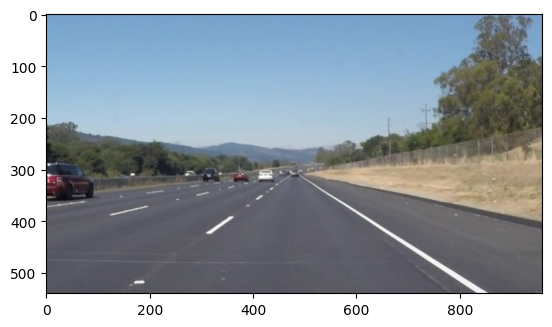

In [57]:
# Reading in an image
image = mpimg.imread("./Test_Images/solidWhiteRight.jpg")
# --- Temporal smoothing state (persists across frames) ---
prev_lane = {
    "left":  {"slope": None, "x": None},
    "right": {"slope": None, "x": None},
}

ALPHA = 0.2   # 0.1 = smoother/laggier, 0.3 = quicker/more jitter
HEIGHT_R = 0.65
# Plotting
print("This image is : ", type(image), "with dimensions: ", image.shape)
plt.imshow(image)

### Ideas for Lane Detection Pipeline

Some OpenCV functions (beyond those introduced in the lesson) that might be useful in this project are:

```cv2.inRange()``` for color selection.<br>
```cv2.fillPoly()``` for region selection.<br>
```cv2.line()``` to draw lines on an image given endpoints.<br>
```cv2.addWeighted()``` to overlay two images.<br>
```cv2.cvtColor()``` to grayscale or change color.<br>
```cv2.imwrite()``` to output images to file.<br>
```cv2.bitwise_and()``` to apply a mask to an image.<br>
<br>
Check out the OpenCV documentation to learn about these and discover even more awesome functionality.

### Useful Functions with their definitions

Below are some helper functions to help get you started.

In [58]:
import math

def grayscale(img):
    """
    Applies the grayscale transform.

    This will return an image with only one color channel
    but NOTE: to see the returned image as grayscale
    (assuming your grayscaled image is called 'gray')
    you should call plt.imshow(gray, cmap='gray')    
    """

    return cv2.cvtColor(img, cv2.COLOR_RGB2GRAY)
    # Or use BGR2GRAY if you read an image with cv2.imread()
    # return cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)


def canny(img, low_threshold, high_threshold):
    """ Applies the Canny transform"""
    return cv2.Canny(img, low_threshold, high_threshold)


def gaussian_blur(img, kernel_size):
    """Applies a Gaussian Noise kernel"""
    return cv2.GaussianBlur(img, (kernel_size, kernel_size), 0)


def region_of_interest(img, vertices):
    """
    Applies an image mask.

    Only keeps the region of the image defined by the
    polygon formed from 'vertices'. The rest of the image
    is set to black. 'Vertices' should be a numpy array of
    integer points.
    """

    # Defining a blank mask to start with
    mask = np.zeros_like(img)

    # Defining a 3 channel or 1 channel color to fill the mask with depending on the input image
    if len(img.shape) > 2:
        channel_count = img.shape[2]
        ignore_mask_color = (255,) * channel_count
    else:
        ignore_mask_color = 255
    
    # Filling pixels inside the polygon defined by "vertices" with the fill color
    cv2.fillPoly(mask, vertices, ignore_mask_color)

    # Returning the image only where the mask pixels are nonzero
    masked_image = cv2.bitwise_and(img, mask)
    
    return masked_image


def draw_lines(img, lines, color=[255, 0, 0], thickness=2):
    """
    this is the function you might want to use as a starting point once you want to
    average/extrapolate the line segments you detect to map out the full
    extent of the lane (going from the result shown in raw-lines-example.mp4
    to that shown in P1_example.mp4).

    Think about things like separating line segments by their
    slope ((y2-y1)/(x2-x1)) to decide which segments are part of the left
    line vs. the right line. Then, you can average the position of each of
    the lines and extrapolate to the top and bottom of the lane.

    This function draws `lines' with `color' and `thickness'.
    Lines are drawn on the image inplace (mutates the image).
    If you want to make the lines semi-transparent, think about combining
    this function with the weighted_img() function below
    """

    for line in lines:
        for x1,y1,x2,y2 in line:
            cv2.line(img, (x1, y1), (x2, y2), color, thickness)


def hough_lines(img, rho, theta, threshold, min_line_len, max_line_gap):
    """
    'img' should be the output of a Canny transform.

    Returns an image with hough lines drawn.
    """
    
    lines = cv2.HoughLinesP(img, rho, theta, threshold, np.array([]), minLineLength=min_line_len, maxLineGap=max_line_gap)
    line_img = np.zeros((img.shape[0], img.shape[1], 3), dtype=np.uint8)
    draw_lines(line_img, lines)
    return line_img

    # Python has support for math symbols.


def weighted_img(img, initial_img, a=0.8, b=1., y=0.):
    """
    'img' is the output of the hough_lines(), An image with lines drawn on it.
    Should be a blank image (all black) with lines drawn on it.

    `initial_img' should be the image before any processing.

    The result image is computed as follows:

    initial_img * a + img * ß + Y
    
    NOTE: initial_img and img must be the same shape!
    """
    return cv2.addWeighted(initial_img, a, img, b, y)

### Test Images and Video

You should make sure your pipeline works well on these images and on the video before trying it on your real-time streaming video.

In [59]:
# The OS module in Python provides functions for interacting with the operating system.

import os
# This returns the contents of a directory
os.listdir("./Test_Images/")

['exitRamp.png',
 'solidYellowCurve2.jpg',
 'solidYellowLeft.jpg',
 'whiteCarLaneSwitch.jpg',
 'exit-ramp.jpg',
 'solidWhiteCurve.jpg',
 'solidWhiteRight.jpg',
 'solidYellowCurve.jpg',
 'test.jpg']

### Build a Lane Finding Pipeline

Build the pipeline and run your solution on all test_images. Make copies into the test_images_output directory, and you can use the images in your writeup
report.

Try tuning the various parameters, especially the low and high Canny thresholds as well as the Hough lines parameters.

### Test on Videos
You know what's cooler than drawing lanes over images? Drawing lanes over video!

We can test our solution on two provided videos:

```solidwhiteRight.mp4```

```solidYellowLeft.mp4```

<br>

**Note: if you get an import error when you run the next cell, try changing your kernel (select the Kernel menu above -- > Change Kernel). Still have
problems? Try relaunching Jupyter Notebook from the terminal prompt. Also, consult the forums for more troubleshooting tips.**

<br>

**If you get an error that looks like this:**

    NeedDownloadError: Need ffmpeg exe.
    You can download it by calling:
    imageio.plugins.ffmpeg.download()

In [60]:
# Import everything needed to edit/save/watch video clips
from unittest import result
from moviepy.editor import VideoFileClip
from IPython.display import HTML

def process_image(image):
    gray=grayscale(image)
    blur=gaussian_blur(gray, 9)
    cany = canny(blur, 50, 150)
    vetrices = np.array([[[0, image.shape[0]], [450 , 300], [580 , 300], [image.shape[1], image.shape[0]]]], dtype=np.int32)
    result = region_of_interest(cany, vetrices)
    #result = grayscale(image)
    #result = gaussian_blur(result, 3)
    plt.imshow(result, cmap='gray')

    rho = 1
    theta = np.pi / 180
    threshold = 50
    min_line_len = 100 
    max_line_gap = 150

    img = result
    lines = cv2.HoughLinesP(img, rho, theta, threshold, np.array([]), minLineLength=min_line_len, maxLineGap=max_line_gap)
    lines = process_lines(lines, image)
    line_img = np.zeros((*img.shape, 3), dtype=np.uint8)
    draw_lines(line_img, lines, thickness = 8)
    result = weighted_img(line_img, image, b=0.5)

    return result


def process_lines(lines, image):
    """
    Computes left/right lane lines and applies temporal smoothing (EMA) on:
      - slope
      - x-intercept at the bottom of the image
    """
    global prev_lane, ALPHA, HEIGHT_R

    # results[0] = left, results[1] = right
    results = [{"slope": 0.0, "x": 0.0, "weight": 0.0} for _ in range(2)]
    f_lines = []

    if lines is None:
        lines = []

    for line in lines:
        for x1, y1, x2, y2 in line:
            if x1 == x2:
                continue

            slope = (y1 - y2) / (x1 - x2)

            # intersect x at bottom of image (y = image.shape[0])
            intersect_x = (image.shape[0] - y2) / slope + x2

            # discard invalid
            if intersect_x < 0 or intersect_x >= image.shape[1]:
                continue

            # classify left/right by slope range
            if -0.85 < slope < -0.5:
                idx = 0  # left
            elif 0.5 < slope < 0.85:
                idx = 1  # right
            else:
                continue

            # weight by length^2
            weight = (x1 - x2)**2 + (y1 - y2)**2
            results[idx]["slope"]  += slope * weight
            results[idx]["x"]      += intersect_x * weight
            results[idx]["weight"] += weight

    # helper for EMA
    def ema(prev, cur, alpha):
        return cur if prev is None else (1 - alpha) * prev + alpha * cur

    for idx, one_r in enumerate(results):
        side = "left" if idx == 0 else "right"
    
        found = one_r["weight"] > 0.0

        if found:
            cur_x = one_r["x"] / one_r["weight"]
            cur_slope = one_r["slope"] / one_r["weight"]

            # EMA smooth with previous
            sm_x = ema(prev_lane[side]["x"], cur_x, ALPHA)
            sm_slope = ema(prev_lane[side]["slope"], cur_slope, ALPHA)

            prev_lane[side]["x"] = sm_x
            prev_lane[side]["slope"] = sm_slope
        else:
            # If not found this frame, reuse previous smoothed line if available
            sm_x = prev_lane[side]["x"]
            sm_slope = prev_lane[side]["slope"]

            if sm_x is None or sm_slope is None:
                f_lines.append([[0, 0, 0, 0]])
                continue

        # Build endpoints from smoothed params
        x0 = sm_x
        m  = sm_slope

        y0 = image.shape[0]
        y1 = int(image.shape[0] * HEIGHT_R)

        # y - y0 = m(x - x0)  ->  x = (y - y0)/m + x0
        x1 = (y1 - y0) / m + x0

        point0 = (int(x0), int(y0))
        point1 = (int(x1), int(y1))
        f_lines.append([point0 + point1])

    return f_lines

When putting files in a directory, make sure that it exists. If it doesn't then create it first.

In [61]:
output_folder = r"Test_Video_Outputs"

if not os.path.exists(output_folder):
    os.mkdir(output_folder)

Let's try the one with the solid white lane on the right first...

clip1.duration = 5
clip1.fps      = 25.0
Moviepy - Building video ./Test_Video_Outputs/white_right_output.mp4.
Moviepy - Writing video ./Test_Video_Outputs/white_right_output.mp4



Moviepy - Done !
Moviepy - video ready ./Test_Video_Outputs/white_right_output.mp4


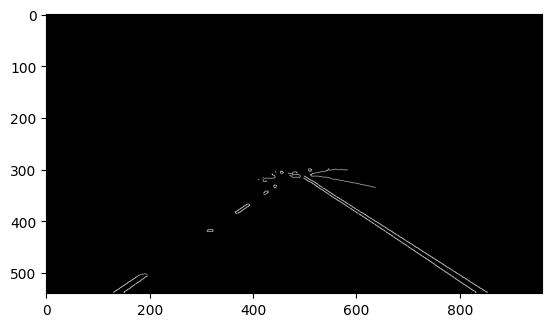

In [62]:
white_right_output = "./Test_Video_Outputs/white_right_output.mp4"

# To speed up the testing process you may want to try your pipeline on a shorter subclip of the video
# To do so add .subcLip(start_second, end_second) to the end of the Line below
# Where start_second and end_second are integer values representing the start and end of the subclip
# You may also uncomment the following line for a subclip of the first 5 seconds

clip1 = VideoFileClip("./Test_Videos/solidWhiteRight.mp4").subclip(0, 5)

print("clip1.duration =", clip1.duration)
print("clip1.fps      =", getattr(clip1, "fps", None))

white_right_clip = clip1.fl_image(process_image)
white_right_clip = white_right_clip.set_duration(clip1.duration).set_fps(clip1.fps)

white_right_clip.write_videofile(white_right_output, audio=False, fps=25)

clip1.close()
white_right_clip.close()


### White Line Output Video

In [63]:
HTML("""<video width="960" height="540" controls>
    <source src="{0}">
     </video>
    """
    .format(white_right_output)
    )

### Improve the draw_lines() function

At this point, if you were successful with making the pipeline and tuning parameters, you probably have the Hough line segments drawn onto the road, but
what about identifying the full extent of the lane and marking it clearly? Think about defining a line to run the full length of the visible lane based on the line
segments you identified with the Hough Transform. Try to average and/or extrapolate the line segments you've detected to map out the full extent of the lane
lines.

Now for the one with the solid yellow lane on the left. This one's more tricky!

Moviepy - Building video ./Test_Video_Outputs/yellow_output.mp4.
Moviepy - Writing video ./Test_Video_Outputs/yellow_output.mp4



Moviepy - Done !
Moviepy - video ready ./Test_Video_Outputs/yellow_output.mp4
CPU times: user 1.19 s, sys: 765 ms, total: 1.96 s
Wall time: 926 ms


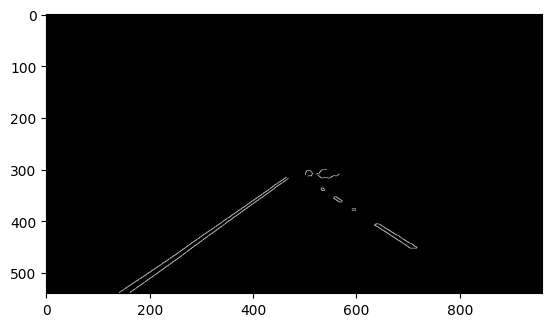

In [64]:
yellow_output = "./Test_Video_Outputs/yellow_output.mp4"

# To speed up the testing process you may want to try your pipeline on a shorter subclip of the video
# To do so add .subcLip(start_second, end_second) to the end of the Line below
# Where start_second and end_second are integer values representing the start and end of the subclip
# You may also uncomment the following Line for a subclip of the first 5 seconds

clip2 = VideoFileClip("./Test_Videos/solidYellowLeft.mp4").subclip(0,5)
yellow_clip = clip2.fl_image(process_image)
%time yellow_clip.write_videofile(yellow_output, audio=False)

### Yellow Line Output Video

In [65]:
HTML("""<video width="960" height="540" controls>
    <source src="{0}">
     </video>
    """
    .format(yellow_output)
    )

### Optional Challenge

Try your lane finding pipeline on the video below. Does it still work? Can you figure out a way to make it more robust?

Moviepy - Building video ./Test_Video_Outputs/challenge_output.mp4.
Moviepy - Writing video ./Test_Video_Outputs/challenge_output.mp4



Moviepy - Done !
Moviepy - video ready ./Test_Video_Outputs/challenge_output.mp4
CPU times: user 1.97 s, sys: 1.07 s, total: 3.04 s
Wall time: 1.78 s


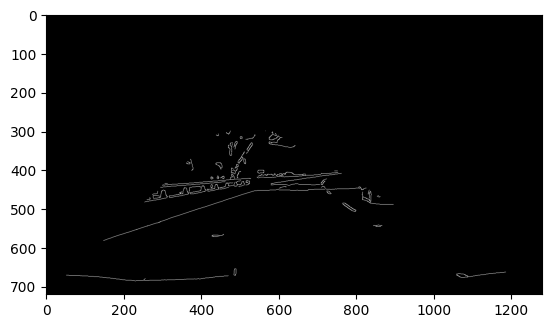

In [66]:
challenge_output = "./Test_Video_Outputs/challenge_output.mp4"

# To speed up the testing process you may want to try your pipeline on a shorter subclip of the video
# To do so add .subcLip(start_second, end_second) to the end of the Line below
# Where start_second and end_second are integer values representing the start and end of the subclip
# You may also uncomment the following line for a subclip of the first 5 seconds

clip3 = VideoFileClip("./Test_Videos/challenge.mp4").subclip(0,5)
challenge_clip = clip3.fl_image(process_image)
%time challenge_clip.write_videofile(challenge_output, audio=False)

### Challenge Output Video

In [67]:
HTML("""<video width="960" height="540" controls>
    <source src="{0}">
     </video>
    """
    .format(challenge_output)
    )